In [1]:
import warnings

warnings.filterwarnings("ignore")

import sys
import os

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# plt.style.use("ggplot")
sns.set_theme(style="ticks")
sns.set_context("paper")
sns.color_palette("husl", 8)
# plt.style.use('grayscale')

import re
from tqdm import tqdm
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.linear_model import (
    LogisticRegressionCV,
    LassoCV,
    Lasso,
    ElasticNetCV,
    LogisticRegression,
)
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold, KFold
from sklearn.utils import resample
sys.path.append(os.path.abspath("../"))
from dmldid.model_rcs import DMLDiD_RCS
#from dmldid.model_rcs_patched import DMLDiD_RCS   # ← ファイル名に合わせて
from dmldid.zero_inflated_model import ZeroInflatedModel

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.linear_model import LogisticRegressionCV, LassoCV

class ORIGINAL_DMLDiD_RCS:
    """
    Chang(2020) Original ver
    """

    def __init__(
        self,
        d_model=LogisticRegressionCV(
            cv=5, random_state=333, penalty="l1", solver="saga"
        ),
        l2k_model=LassoCV(cv=5, random_state=333),
        **kwargs,
    ):
        # params
        self._att_list = []
        self._att = None
        # model
        self.d_model = d_model
        self.l2k_model = l2k_model
        # ---- 追加: 推論用の入れ物（点推定と影響スコア）----
        self.theta_hat = None
        self.psi_ = None

    def fit(
        self,
        df: pd.DataFrame,
        y_col: str,
        d_col: str,
        t_col: str,
        X_cols: list,
        sim_cnt=1,
        eps=0.03,
        base_random_seed=0,
        progress_plot=False,
        d_model_t0_only=True,
        l2k_ps_weight=False,
        **kwargs,
    ):
        K = 2  # ２分割
        self._att_list = []  # 初期化

        # 安全のため index を連番に（アルゴリズムは不変）
        df = df.reset_index(drop=True).copy()

        for l in range(sim_cnt):
            if progress_plot & (l > 0):
                clear_output(wait=True)
                print(f"{l}. att : ", np.mean(self._att_list))

            df_set = train_test_split(
                df,
                random_state=base_random_seed + l,
                test_size=0.5,
                stratify=df[[t_col, d_col]],
            )
            temp_att = []

            # ---- 追加: 各観測のスコア(s1+s2)をためる（ラベル代入で安全）----
            s_all = pd.Series(np.nan, index=df.index)

            for i in range(K):
                k = 0 if i == 0 else 1
                c = 1 if i == 0 else 0

                if d_model_t0_only:
                    self.d_model.fit(
                        df_set[c].query(f"{t_col}<1")[X_cols],
                        df_set[c].query(f"{t_col}<1")[d_col]
                    )
                else:
                    self.d_model.fit(df_set[c][X_cols], df_set[c][d_col])

                ghat = np.clip(
                    self.d_model.predict_proba(df_set[k][X_cols])[:, 1],
                    eps,
                    1 - eps,
                )

                lamda_hat = df_set[k][t_col].mean()
                p_hat = df_set[k][d_col].mean()

                # l2kmodel for T=1 and T=0 for control
                l2kmodel_t1_c = self.l2k_model
                l2kmodel_t0_c = self.l2k_model

                control_y = df_set[c].query(f"{d_col} < 1")[y_col]
                control_x = df_set[c].query(f"{d_col} < 1")[X_cols]
                t_index = df_set[c].query(f"{d_col} < 1 & {t_col} > 0").index
                not_t_index = df_set[c].query(f"{d_col} < 1 & {t_col} < 1").index

                if l2k_ps_weight:
                    ps = np.clip(
                        self.d_model.predict_proba(control_x.loc[t_index])[:, 1],
                        eps,
                        1 - eps,
                    )
                    l2kmodel_t1_c.fit(
                        control_x.loc[t_index],
                        control_y.loc[t_index],
                        sample_weight= ps/(1-ps)
                    )
                    ps = np.clip(
                        self.d_model.predict_proba(control_x.loc[not_t_index])[:, 1],
                        eps,
                        1 - eps,
                    )
                    l2kmodel_t0_c.fit(
                        control_x.loc[not_t_index],
                        control_y.loc[not_t_index],
                        sample_weight= ps/(1-ps)
                    )
                else:
                    l2kmodel_t1_c.fit(control_x.loc[t_index], control_y.loc[t_index])
                    l2kmodel_t0_c.fit(
                        control_x.loc[not_t_index], control_y.loc[not_t_index]
                    )

                l2k_hat_control_pre = l2kmodel_t0_c.predict(df_set[k][X_cols])
                l2k_hat_control_post = l2kmodel_t1_c.predict(df_set[k][X_cols])

                l2k_hat_control = (
                    l2k_hat_control_post * df_set[k][t_col]
                    + l2k_hat_control_pre * (1 - df_set[k][t_col])
                )

                # l2kmodel for T=1 and T=0 for treated
                l2kmodel_t1_t = self.l2k_model
                l2kmodel_t0_t = self.l2k_model

                treat_y = df_set[c].query(f"{d_col} > 0")[y_col]
                treat_x = df_set[c].query(f"{d_col} > 0")[X_cols]
                t_index = df_set[c].query(f"{d_col} > 0 & {t_col} > 0").index
                not_t_index = df_set[c].query(f"{d_col} > 0 & {t_col} < 1").index

                l2kmodel_t1_t.fit(treat_x.loc[t_index], treat_y.loc[t_index])
                l2kmodel_t0_t.fit(
                    treat_x.loc[not_t_index], treat_y.loc[not_t_index]
                )

                l2k_hat_treat_pre = l2kmodel_t0_t.predict(df_set[k][X_cols])
                l2k_hat_treat_post = l2kmodel_t1_t.predict(df_set[k][X_cols])

                # --------
                # 1st stage（ベクトル）
                outcome_estimated_diff = df_set[k][y_col] - l2k_hat_control

                s1 = (
                    (df_set[k][t_col] - lamda_hat)
                    / (lamda_hat * (1 - lamda_hat))
                    * outcome_estimated_diff
                    * (df_set[k][d_col] - ghat)
                    / ((1 - ghat) * p_hat)
                )

                _att = s1.mean()

                # --------
                # 2nd stage（ベクトル）
                estimated_diff_post_d = df_set[k][d_col] * (
                    l2k_hat_treat_post - l2k_hat_control_post
                ) / p_hat

                w_dt1 = df_set[k][d_col] * df_set[k][t_col]
                estimated_diff_post_dt1 = w_dt1 * (
                    l2k_hat_treat_post - l2k_hat_control_post
                ) / (w_dt1.mean())

                estimated_diff_pre_d = df_set[k][d_col] * (
                    l2k_hat_treat_pre - l2k_hat_control_pre
                ) / p_hat

                w_dt0 = df_set[k][d_col] * (1 - df_set[k][t_col])
                estimated_diff_pre_dt0 = w_dt0 * (
                    l2k_hat_treat_pre - l2k_hat_control_pre
                ) / (w_dt0.mean())

                s2 = (estimated_diff_post_d - estimated_diff_post_dt1) - (
                    estimated_diff_pre_d -  estimated_diff_pre_dt0
                )

                _att += s2.mean()
                temp_att.append(_att)

                # ---- 追加: このfoldの各観測スコアを保存（予測側のみ）----
                idxk = df_set[k].index
                s_all.loc[idxk] = (s1 + s2).to_numpy()

            # 既存の点推定の更新（そのまま）
            self._att_list.append(np.mean(temp_att))

            # ---- 追加: 推論用（導関数補正なしの最小IF）----
            self.theta_hat = self._att_list[-1]
            self.psi_ = (s_all - self.theta_hat).to_numpy()

    def att(self):
        return np.mean(self._att_list)
    
    def sim_att_result(self):
        return self._att_list

    # ---- 追加: 乗数ブート（Rademacher推奨）----
    def multiplier_bootstrap(self, B=999, random_state=1, kind="rademacher"):
        if self.psi_ is None or self.theta_hat is None:
            raise RuntimeError("Call fit() first to compute psi_ / theta_hat.")
        n = len(self.psi_)
        rng = np.random.default_rng(random_state)
        if kind.lower() in ("rademacher", "rad"):
            xi = rng.choice([-1.0, 1.0], size=(B, n))
        elif kind.lower() in ("normal", "gaussian"):
            xi = rng.standard_normal(size=(B, n))
        else:
            raise ValueError("kind must be 'rademacher' or 'normal'")
        # θ* = θ̂ + n^{-1/2} * (1/n) Σ ξ_i ψ_i
        shifts = (xi @ self.psi_) / (n ** 1.5)
        theta_star = self.theta_hat + shifts
        se = float(np.std(theta_star - self.theta_hat, ddof=1))
        ci = (float(np.quantile(theta_star, 0.025)),
              float(np.quantile(theta_star, 0.975)))
        return se, ci, theta_star

def stratified_pairs_boot_chang(df, y_col, d_col, t_col, X_cols,
                                B=999, seed=2025, by=("D","T"),
                                base_kwargs=None):
    rng = np.random.default_rng(seed)
    thetas = []

    for b in tqdm(range(B)):
        # 層化 resample（(D,T) か T のみ）
        blocks = []
        for _, g in df.groupby(list(by), sort=False):
            idx = rng.integers(0, len(g), len(g))
            blocks.append(g.iloc[idx])
        dfb = pd.concat(blocks, ignore_index=True)

        est = ORIGINAL_DMLDiD_RCS()  # 元のクラスのまま
        kw = dict(sim_cnt=1, d_model_t0_only=False, l2k_ps_weight=False)
        if base_kwargs:
            kw.update(base_kwargs)
        est.fit(dfb, y_col, d_col, t_col, X_cols, **kw)
        thetas.append(est.att())

    thetas = np.asarray(thetas)
    se = thetas.std(ddof=1)
    ci = (np.quantile(thetas, 0.025), np.quantile(thetas, 0.975))
    return se, ci, thetas

# original data processing
Somewhat improper processing, but we use the data pipeline of Chang (2020) as is to make the conditions the same as in the original paper.
https://github.com/NengChiehChang/Diff-in-Diff/blob/master/Table%202/DMLML.R

## issue
I have communicated the problems with this process in the  [issue](https://github.com/NengChiehChang/Diff-in-Diff/issues/1) of the original R repository.
The major problems are as follows: 
- Categorical variables should be explicitly binary processed
- inclusion of time binary T in the covariate

In [3]:
DATA_PATH = "data/Bribes_Regression.dta"

df = pd.read_stata(DATA_PATH)
df = df.rename(columns={"ba": "Y", "tariff_change_2008": "D", "post_2008": "T"})
df.head().T
print("Main Variables null ratio:\n", df[["Y", "D", "T"]].isnull().sum() / len(df))
df = df.dropna(subset=["Y", "D", "T"]).reset_index(drop=True)

Main Variables null ratio:
 Y    0.000351
D    0.027729
T    0.000000
dtype: float64


In [4]:
df.groupby("reason_bribe").agg({"Y" : ["count", "mean"]})

Y             
                        count         mean
reason_bribe                              
clearing agent red tape    52   784.849487
congestion                428   827.915649
delay                      21  2679.551270
jump depot                  6  4921.117188
jump inspection            23  8478.886719
jump queue                253  1072.846436
jump reg                   20  6384.299805
late arrival              107  1367.991211
misclassification          25  3904.841064
misreporting quantities     3  1306.491211
other                       3  7665.512207
red tape                   45  8460.256836
smuggling                   1  1306.491211
undervalue                574  4214.176270
wrong docs                 30  5896.630371

In [5]:
del df["day_w_arrival_post2008"]
del df["psi_post_2008"]
df = pd.concat(
    [
        df,
        pd.get_dummies(df["reason_bribe"], drop_first=False, prefix="reason_bribe"),
        pd.get_dummies(df["b_recipient"], drop_first=False, prefix="b_recipient"),
        pd.get_dummies(df["day_w_arrival"], drop_first=False, prefix="day_w_arrival"),
        pd.get_dummies(df["monitor"], drop_first=False, prefix="monitor"),
        pd.get_dummies(df["psi"], drop_first=False, prefix="psi"),
        pd.get_dummies(df["term"], drop_first=False, prefix="term"),
        pd.get_dummies(
            df["clear_agent"].fillna(99).astype(int),
            drop_first=True,
            prefix="clear_agent",
        ),
        pd.get_dummies(
            df["hc_group"].fillna(99).astype(int), drop_first=False, prefix="hc_group"
        ),
    ],
    axis=1,
).drop(
    [
        "reason_bribe",
        "b_recipient",
        "day_w_arrival",
        "monitor",
        "psi",
        "term",
        "clear_agent",
        "hc_group",
    ],
    axis=1,
)

df.head().T

,0,1,2,3,4
ship_id,2.0,3.0,4.0,5.0,6.0
month_arrival,3.0,12.0,8.0,8.0,12.0
year,4.0,1.0,4.0,4.0,1.0
hc_4digits,8215.0,2202.0,8703.0,8703.0,2202.0
bp,0.0,1.0,1.0,0.0,1.0
...,...,...,...,...,...
hc_group_12,1.0,0.0,0.0,0.0,0.0
hc_group_13,0.0,0.0,0.0,0.0,0.0
hc_group_14,0.0,0.0,1.0,1.0,0.0
hc_group_15,0.0,0.0,0.0,0.0,0.0


In [6]:
# Excluding those too correlated with D
X_cols = [
    #"tariff2007", # 削除候補
    "lvalue_tonnage",
    "differentiated",
    "agri",
    "perishable",
    "dfs",
    "rsa",
     "value_shipment_metical",  # 追加
     "tonnage"# 追加
]
monitor_cols = [col for col in df.columns if "monitor" in col]
term_cols = [col for col in df.columns if "term" in col]
dwa_cols = [col for col in df.columns if "day_w_arrival" in col]
psi_cols = [col for col in df.columns if "psi" in col]
clear_agent_cols = [col for col in df.columns if "clear_agent" in col]
hc_group_cols = [col for col in df.columns if "hc_group" in col]

X_cols = (
    X_cols + dwa_cols + psi_cols + clear_agent_cols + hc_group_cols + term_cols + ['monitor_No', 'monitor_Yes']
)  # monitor_cols
y_col = "Y"
d_col = "D"
t_col = "T"

In [7]:
upper_limit = np.percentile(df["Y"], 99)

df_full =  df[X_cols + [y_col , d_col , t_col]]#.query("Y <= @upper_limit").reset_index(drop=True)
print(df_full.shape)

(2769, 60)


- tariff_change_post2008: Tariff change category × POST
- tariff_change_2008: Tariff change category
- tariff_reduction_post2008: Tariff reduction × POST
- tariff_reduction: Tariff reduction
- post2008: POST
- differentiated: Differentiated product
- agri: Agricultural product
- psi_not_inspected: Pre-shipment inspection
- perishable: Perishable product
- fsize: Large firm
- lvalue_tonnage: log shipment value per ton
- clear_agent: Clearing agent fixed effects

- hc_4digits: Product four-digit HS code
- term: Terminal
- day_w_arrival_*: Day of the week arrival
- rsa: Product from South Africa
- baseline_tariff: Baseline tariff



In [8]:
pd.DataFrame({"missing_ratio": df_full.isnull().sum() / len(df_full)}).query(
    "missing_ratio > 0"
)

,missing_ratio
lvalue_tonnage,0.544240
agri,0.000722
value_shipment_metical,0.059588
tonnage,0.527266


In [9]:
df_full = df_full.dropna(subset=["agri"])

In [10]:
null_value_df = (
    df_full.assign(lvalue_tonnage_null=df_full["lvalue_tonnage"].isnull()).query("T>0")
    .groupby(["lvalue_tonnage_null"])[["D", "Y"]]
    .mean()
    .T
)
null_value_df
null_value_df["diff"] = null_value_df.diff(axis=1)[1]
print("T==1")
print(null_value_df)
print("T==0")
null_value_df = (
    df_full.assign(lvalue_tonnage_null=df_full["lvalue_tonnage"].isnull()).query("T<1")
    .groupby(["lvalue_tonnage_null"])[["D", "Y"]]
    .mean()
    .T
)
null_value_df
null_value_df["diff"] = null_value_df.diff(axis=1)[1]
print(null_value_df)

T==1
lvalue_tonnage_null       False        True        diff
D                      0.197842    0.478261    0.280419
Y                    996.435730  747.832092 -248.603638
T==0
lvalue_tonnage_null        False         True         diff
D                       0.406667     0.653521     0.246854
Y                    6698.556641  4163.372559 -2535.184082


In [11]:
from scipy.stats import ttest_ind

group_null = df_full[df_full["lvalue_tonnage"].isnull()].query("T>0")
group_not_null = df_full[~df_full["lvalue_tonnage"].isnull()].query("T>0")

t_test_results = {}
for col in ["D", "Y"]:
    t_stat, p_value = ttest_ind(group_null[col], group_not_null[col], nan_policy="omit")
    t_test_results[col] = {"t_stat": t_stat, "p_value": p_value}


t_test_results_df = pd.DataFrame(t_test_results).T
print("T==1")
print(t_test_results_df)

group_null = df_full[df_full["lvalue_tonnage"].isnull()].query("T<1")
group_not_null = df_full[~df_full["lvalue_tonnage"].isnull()].query("T<1")

t_test_results = {}
for col in ["D", "Y"]:
    t_stat, p_value = ttest_ind(group_null[col], group_not_null[col], nan_policy="omit")
    t_test_results[col] = {"t_stat": t_stat, "p_value": p_value}


t_test_results_df = pd.DataFrame(t_test_results).T
print("T==0")
print(t_test_results_df)

T==1
      t_stat       p_value
D  14.723945  6.289741e-47
Y  -1.378484  1.681905e-01
T==0
     t_stat       p_value
D  5.265428  2.076097e-07
Y -2.472303  1.375426e-02


# 離散化する?

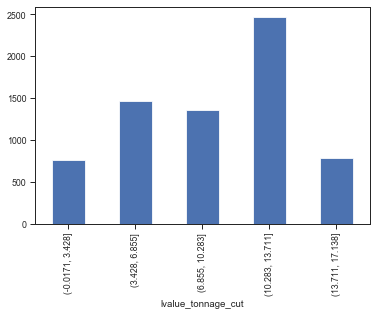

In [12]:
df_full.assign(lvalue_tonnage_cut=pd.cut(df_full["lvalue_tonnage"], 5)).groupby(
    "lvalue_tonnage_cut"
)["Y"].mean().plot.bar()

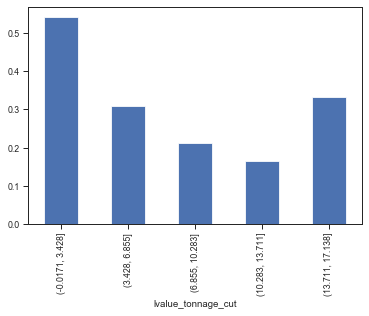

In [13]:
df_full.assign(lvalue_tonnage_cut=pd.cut(df_full["lvalue_tonnage"], 5)).groupby(
    "lvalue_tonnage_cut"
)["D"].mean().plot.bar()

In [14]:
df_full = df_full.dropna()
# df_full = df_full.assign(
#     lvalue_tonnage_label=pd.cut(df_full["lvalue_tonnage"], 5, labels=False),
#     lvalue_tonnage_null=df_full["lvalue_tonnage"].isnull().astype(int),
# )
# df_full = pd.concat(
#     [
#         df_full,
#         pd.get_dummies(df_full["lvalue_tonnage_label"], drop_first=False, prefix="lvalue_tonnage"),
       
#     ],
#     axis=1,
# ).drop(
#     [
#         "lvalue_tonnage_label",
#         "lvalue_tonnage",
#     ],
#     axis=1,
# )
# lvalue_tonnage_cols = [col for col in df_full.columns if "lvalue_tonnage" in col]

In [15]:
# X_cols = [
#     # "lvalue_tonnage", # remove
#     "differentiated",
#     "agri",
#     "perishable",
#     "dfs",
#     "rsa",

# ]

# X_cols = (
#     X_cols + dwa_cols + psi_cols + clear_agent_cols + hc_group_cols + term_cols + ['monitor_No', 'monitor_Yes'] + lvalue_tonnage_cols
# )  # monitor_cols

In [16]:
assert df_full.isnull().sum().sum() == 0

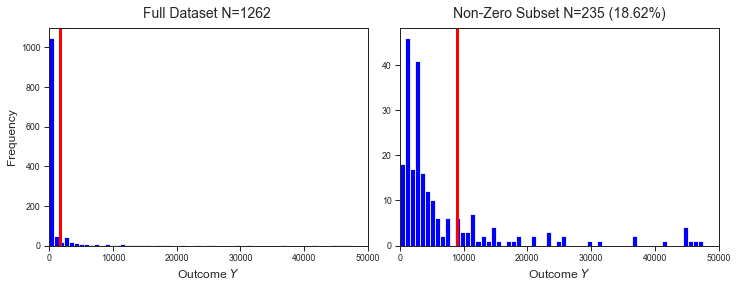

In [17]:
fig, axs = plt.subplots(
    1, 2, sharex="col", figsize=(12, 4), gridspec_kw=dict(hspace=0.5, wspace=0.1)
)
axs = axs.ravel()
# ビンの境界を計算
global_min = df_full["Y"].min()
global_max = df_full["Y"].max()
bins = np.linspace(global_min, global_max, 100)


df_full["Y"].hist(bins=bins, ax=axs[0], color="blue", grid=False)
axs[0].set_title(f"Full Dataset N={len(df_full)} ", fontsize=14, pad=10)
axs[0].axvline(x=df_full["Y"].mean(), color="red", alpha=1, lw=3)
axs[0].set_xlabel("Outcome $Y$", fontsize=12)
axs[0].set_ylabel("Frequency", fontsize=12)
axs[0].set_xlim(0, 50000)

df_full.query("Y>0")["Y"].hist(bins=bins, ax=axs[1], color="blue", grid=False)
axs[1].set_title(
    f"Non-Zero Subset N={len(df_full.query('Y>0'))} ({100*len(df_full.query('Y>0')) / len(df_full):.2f}%)",
    fontsize=14,
    pad=10,
)
axs[1].axvline(x=df_full.query('Y>0')["Y"].mean(), color="red", alpha=1, lw=3)
axs[1].set_xlabel("Outcome $Y$", fontsize=12)
axs[1].set_xlim(0, 50000)


fig.savefig("../fig/empirical_example_outcome_hist.png", dpi=600, bbox_inches="tight")

plt.show()

## Checking PS common support

In [18]:
K = 2
df_set = train_test_split(df_full, random_state=0, test_size=0.5)
for i in range(K):
    k = 0 if i == 0 else 1
    c = 1 if i == 0 else 0
    d_model = LGBMClassifier(random_state=0)
    d_model.fit(df_set[c][X_cols],  df_set[c][d_col])
    df_set[k]["ps_lgbm"] = d_model.predict_proba(df_set[k][X_cols])[:, 1]
    l_d_model = LogisticRegressionCV(random_state=0)
    l_d_model.fit(df_set[c][X_cols],  df_set[c][d_col])
    df_set[k]["ps_linear"] = l_d_model.predict_proba(df_set[k][X_cols])[:, 1]
ps_check_df = pd.concat(df_set)

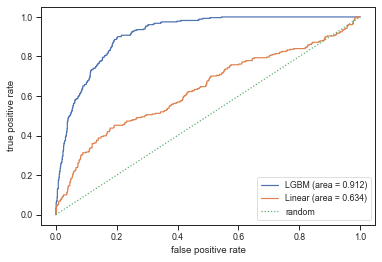

In [19]:
auc_score_lgbm = roc_auc_score(y_true=ps_check_df["D"], y_score=ps_check_df["ps_lgbm"])
auc_score_linear = roc_auc_score(y_true=ps_check_df["D"], y_score=ps_check_df["ps_linear"])
fpr, tpr, thresholds = roc_curve(y_true=ps_check_df["D"], y_score=ps_check_df["ps_lgbm"])
l_fpr, l_tpr, l_thresholds = roc_curve(y_true=ps_check_df["D"], y_score=ps_check_df["ps_linear"])
plt.plot(fpr, tpr, label="LGBM (area = %0.3f)" % auc_score_lgbm )
plt.plot(l_fpr, l_tpr, label="Linear (area = %0.3f)" % auc_score_linear )
plt.plot([0, 1], [0, 1], linestyle=":", label="random")

plt.legend()
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.show()

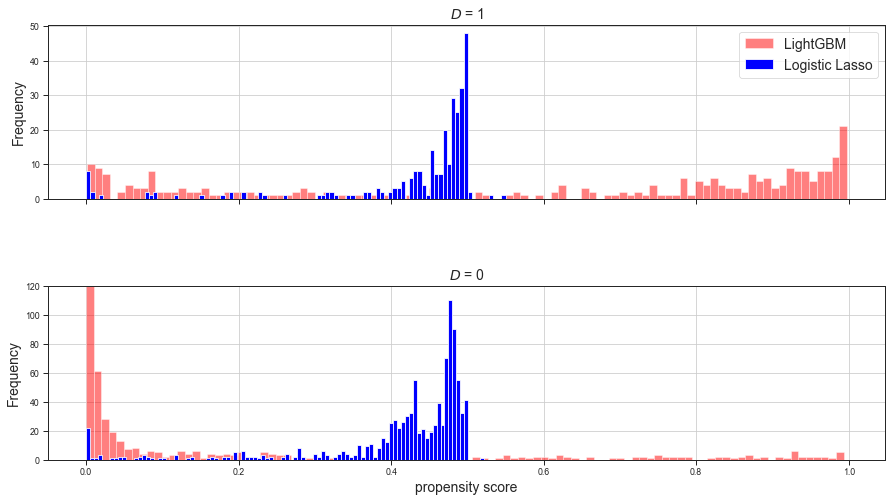

In [20]:
# 図を作成
fig, axes = plt.subplots(2, 1, sharex="col", figsize=(15, 8), gridspec_kw=dict(hspace=0.5))
axes = axes.ravel()
treated_data = ps_check_df.query("D>0")["ps_lgbm"]
untreated_data = ps_check_df.query("D<1")["ps_lgbm"]
treated_data.hist(bins=100, ax=axes[0], color="red", label="lgbm",alpha=0.5)
untreated_data.hist(bins=100, ax=axes[1], color="red", label="lgbm",alpha=0.5)

treated_data = ps_check_df.query("D>0")["ps_linear"]
untreated_data = ps_check_df.query("D<1")["ps_linear"]
# Treated 
treated_data.hist(bins=100, ax=axes[0], color="blue", label="linear")
axes[0].set_title("$D$ = 1", fontsize=14)
axes[0].set_ylabel("Frequency", fontsize=14)
# Untreated
untreated_data.hist(bins=100, ax=axes[1], color="blue", label="linear")
axes[1].set_title("$D$ = 0", fontsize=14)
axes[1].set_ylim(0,120)
axes[1].set_xlabel("propensity score",  fontsize=14)
axes[1].set_ylabel("Frequency", fontsize=14)


# レイアウト調整
plt.tight_layout()
axes[0].legend(["LightGBM", "Logistic Lasso"], loc="upper right", fontsize=14)
fig.savefig("../fig/empilical_example_common_support.png", dpi=600, bbox_inches="tight")
plt.show()

In [21]:
importance = pd.DataFrame(d_model.feature_importances_, index=X_cols, columns=['importance'])
display(importance.sort_values(by="importance",ascending=False).head(20))

,importance
lvalue_tonnage,831
value_shipment_metical,584
tonnage,208
psi_inspected,78
day_w_arrival_Saturday,62
agri,56
clear_agent_6,49
day_w_arrival_Sunday,48
day_w_arrival_Wednesday,45
hc_group_13,45


In [22]:
# The support of the ps of the treated is a subset of the support for the untreated
tg_cutpoint = pd.cut(ps_check_df.query("D > 0")["ps_linear"], 5).unique()


def adjust_cutpoint(x):
    try:
        return [_point for _point in tg_cutpoint if x in _point][0]
    except:
        return "ommit_data"


ps_check_df["ps_group"] = ps_check_df["ps_linear"].apply(adjust_cutpoint)

pd.pivot_table(ps_check_df, values="Y", index="D", columns="ps_group", aggfunc="count")

ps_group,"(-0.00055, 0.11]","(0.11, 0.22]","(0.22, 0.33]","(0.33, 0.44]","(0.44, 0.55]",ommit_data
D,,,,,,
0.0,44.0,29.0,46.0,325.0,537.0,NaN
1.0,16.0,7.0,10.0,47.0,200.0,1.0


In [23]:
def cal_abs_mean_diff(df):
    # (avg_d=1 - avg_d=0) / std
    return (
        (
            df.query("D>0").drop("D", axis=1).mean()
            - df.query("D<1").drop("D", axis=1).mean()
        )
        / df.drop("D", axis=1).std()
    ).abs()

unadjusted_balance = cal_abs_mean_diff(ps_check_df[list(X_cols) + ["D"]])

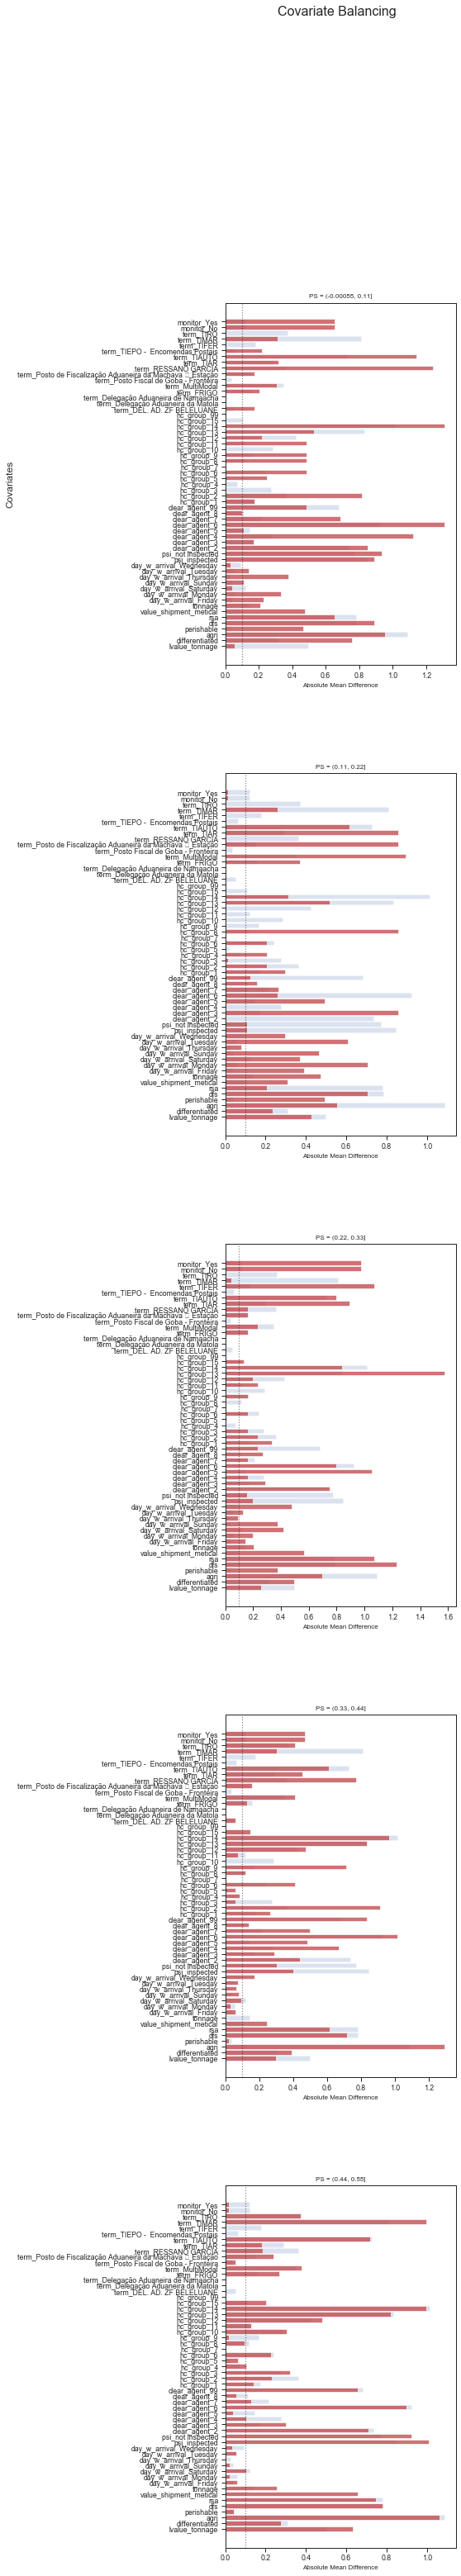

In [24]:
# 本当に特徴量がバランシングできているか確認する
ps_check_df["ps_group"] = ps_check_df["ps_group"].astype("str")
cutpoint_list = [
    cutpoint for cutpoint in ps_check_df["ps_group"].unique() if cutpoint != "ommit_data"
]
cutpoint_list = sorted(cutpoint_list)

fig, ax = plt.subplots(nrows=5,ncols=1, figsize=(5, 50))
plt.subplots_adjust(wspace=0.7,hspace=0.3)
ax = ax.ravel()
for i, cutpoint in enumerate(cutpoint_list):
    _group = ps_check_df.query("ps_group == @cutpoint")
    _group_balance = cal_abs_mean_diff(
        _group[
            list(X_cols) + ["D"]
        ]
    )
    if i == 0:
        ax[i].set_ylabel("Covariates", fontsize=12)

    ax[i].set_title(f"PS = {cutpoint}", fontsize=8)
    ax[i].set_xlabel("Absolute Mean Difference", fontsize=8)
    ax[i].barh(unadjusted_balance.index, unadjusted_balance, alpha=0.2)
    ax[i].barh(_group_balance.index, _group_balance, alpha=0.8, color="r")
    ax[i].axvline(x=0.1,alpha=0.5, color="black",linestyle="dotted")
fig.suptitle("Covariate Balancing", fontsize=16)
plt.show()

## OUTCOME


In [25]:
control_df = df_full.copy()

In [26]:
# import optuna
# from lightgbm import LGBMRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error
# import numpy as np

# np.random.seed(1)
# X = control_df[X_cols + [t_col]]
# y = control_df["Y"]

# # 訓練データとテストデータに分割
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=123)

# # Optunaの目的関数
# def objective(trial):
#     # ハイパーパラメータの空間を定義
#     params = {
#         "num_leaves": trial.suggest_int("num_leaves", 20, 300),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.1, log=True),
#         "n_estimators": trial.suggest_int("n_estimators", 50, 1000),
#         "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
#         "tweedie_variance_power": trial.suggest_float("tweedie_variance_power", 1.1, 2.0),
#         "objective": trial.suggest_categorical("objective", [
#             "tweedie", "regression_l1", "regression_l2", "huber", "poisson"
#         ])
#     }

#     # モデルの作成と学習
#     model = LGBMRegressor(**params, random_state=0)
#     model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=50, verbose=False)

#     # テストデータでのRMSEを計算
#     y_pred = model.predict(X_test)
#     rmse = mean_squared_error(y_test, y_pred, squared=False)

#     return rmse

# # Optunaの最適化プロセス
# study = optuna.create_study(direction="minimize")  # RMSEを最小化
# study.optimize(objective, n_trials=100)  # 試行回数を設定

# # 最適なハイパーパラメータを出力
# print("Best trial:")
# print(f"  Value: {study.best_value}")
# print(f"  Params: {study.best_params}")

# # 最適なパラメータで再学習
# best_params = study.best_params
# best_model = LGBMRegressor(**best_params, random_state=0)
# best_model.fit(X_train, y_train)

# # 最終的なテストデータでのスコア
# final_rmse = mean_squared_error(y_test, best_model.predict(X_test), squared=False)
# print(f"Final RMSE on test data: {final_rmse}")


In [27]:
best_params = {
    "num_leaves": 169,
    "max_depth": 12,
    "learning_rate": 0.005637809073935658,
    "n_estimators": 369,
    "min_child_samples": 64,
    "subsample": 0.9218184522465521,
    "colsample_bytree": 0.9269576031124664,
    "reg_alpha": 6.0614743675324205e-06,
    "reg_lambda": 3.2309969220720016e-07,
    "tweedie_variance_power": 1.910739022387391,
    "objective": "regression_l2",
}

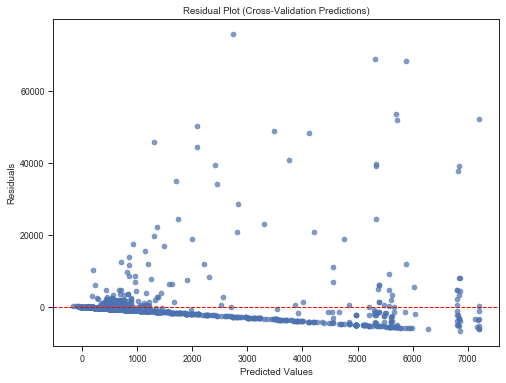

Mean Squared Error (Cross-Validation Predictions): 47009118.7470


In [28]:
# モデルの設定
l2_model = LGBMRegressor(random_state=0,**best_params)

# クロスバリデーションによる予測 (KFoldの例)
cv = KFold(n_splits=2, shuffle=True, random_state=2)
y_pred = cross_val_predict(l2_model, control_df[X_cols + [t_col]], control_df[y_col], cv=cv)

# 残差の計算
residuals = control_df[y_col] - y_pred
control_df["residuals"] = control_df[y_col] - y_pred
control_df["y_pred"] = y_pred
# 残差プロット
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Cross-Validation Predictions)")
plt.show()

# モデル性能評価
mse = mean_squared_error(control_df[y_col], y_pred)
print(f"Mean Squared Error (Cross-Validation Predictions): {mse:.4f}")

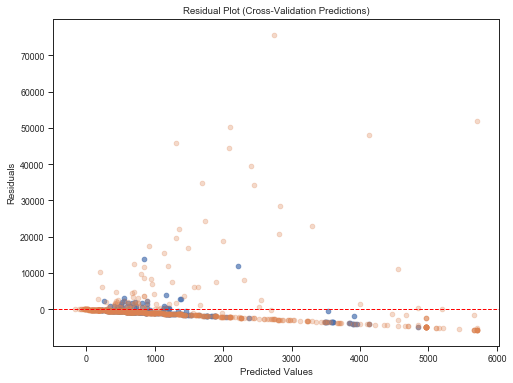

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(control_df.query("T==1 and D ==1").y_pred, control_df.query("T==1 and D ==1").residuals, alpha=0.7)
plt.scatter(control_df.query("T==1 and D ==0").y_pred, control_df.query("T==1 and D ==0").residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Cross-Validation Predictions)")
plt.show()

In [30]:
residuals_table = control_df.pivot_table(index=["D"], columns=["T"], values=["residuals"], aggfunc="mean")
residuals_table["diff"] = residuals_table.diff(axis=1).dropna(axis=1)
residuals_table = pd.concat([residuals_table, residuals_table.diff().tail(1)])
residuals_table.index=["0", "1", "diff"]
residuals_table

residuals                     diff
T             0.0         1.0             
0     -408.906605  -60.884187   348.022418
1     3884.027598 -604.490232 -4488.517831
diff  4292.934203 -543.606045 -4836.540249

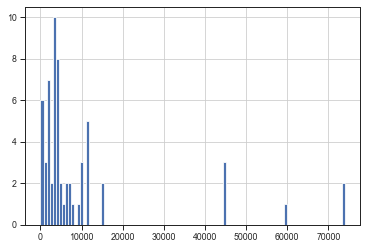

In [31]:
control_df.query("T==0 and D ==1")["Y"].hist(bins=100)

In [32]:
l2_model.fit(control_df[X_cols + [t_col]], control_df[y_col])
importance = pd.DataFrame(l2_model.feature_importances_, index=X_cols+[t_col], columns=['importance'])
display(importance.sort_values(by="importance",ascending=False).head(20))

,importance
lvalue_tonnage,1454
value_shipment_metical,1271
term_TIAUTO,324
clear_agent_6,313
T,269
clear_agent_99,188
tonnage,180
agri,146
clear_agent_3,135
monitor_No,109


# zero infated modeling

In [33]:
zi_model = ZeroInflatedModel(
    classifier=LGBMClassifier(random_state=0),
    regressor=LGBMRegressor(random_state=0),
)

In [34]:
# クロスバリデーションによる予測 (KFoldの例)
K = 2
df_set = train_test_split(df_full, random_state=0, test_size=0.5)
for i in range(K):
    k = 0 if i == 0 else 1
    c = 1 if i == 0 else 0
    zi_model = ZeroInflatedModel(
        classifier=LGBMClassifier(random_state=0),
        regressor=LGBMRegressor(random_state=0,objective="poisson"),
    )
    zi_model.fit(df_set[c][X_cols + [t_col]], df_set[c][y_col])
    df_set[k]["pred_zi"] = zi_model.predict(df_set[k][X_cols + [t_col]])
l2_check_df = pd.concat(df_set)
l2_check_df["residuals"] = l2_check_df[y_col] - l2_check_df["pred_zi"]

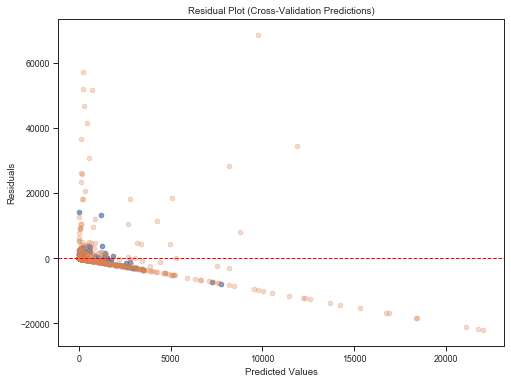

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(l2_check_df.query("T==1 and D ==1").pred_zi, l2_check_df.query("T==1 and D ==1").residuals, alpha=0.7)
plt.scatter(l2_check_df.query("T==1 and D ==0").pred_zi, l2_check_df.query("T==1 and D ==0").residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Cross-Validation Predictions)")
plt.show()

In [36]:
residuals_table = l2_check_df.pivot_table(index=["D"], columns=["T"], values=["Y"], aggfunc="mean")
residuals_table["diff"] = residuals_table.diff(axis=1).dropna(axis=1)
residuals_table = pd.concat([residuals_table, residuals_table.diff().tail(1)])
residuals_table.index=["0", "1", "diff"]
residuals_table

Y                      diff
T             0.0          1.0             
0     4579.687988  1120.100952 -3459.586914
1     9790.020508   495.029633 -9294.991211
diff  5210.332520  -625.071289 -5835.404297

In [37]:
residuals_table = l2_check_df.pivot_table(index=["D"], columns=["T"], values=["residuals"], aggfunc="mean")
residuals_table["diff"] = residuals_table.diff(axis=1).dropna(axis=1)
residuals_table = pd.concat([residuals_table, residuals_table.diff().tail(1)])
residuals_table.index=["0", "1", "diff"]
residuals_table

residuals                    diff
T            0.0         1.0            
0     965.056622  222.931642 -742.124981
1     749.464211 -157.967944 -907.432156
diff -215.592411 -380.899586 -165.307175

# FITTING

In [38]:
boot_n = 1
base_y = df_full.query("T<1 and D >0")[y_col].mean()
base_y

9790.021484375

### zeroinfalted model

In [39]:
_dmldid = DMLDiD_RCS(
    l2k_model=ZeroInflatedModel(
        classifier=LGBMClassifier(random_state=0),
        regressor=LGBMRegressor(random_state=0, objective="poisson"),
    )
)

_dmldid.fit(
    df_full,
    y_col,
    d_col,
    t_col,
    X_cols,
    dmldid=True,
    sim_cnt=1,
    eps=0.05,
    base_random_seed=boot_n,
    l2k_model_separate=True,
    l2k_model_alldata=False,
)

theta = _dmldid.att()
se, ci, _ = _dmldid.multiplier_bootstrap(B=999, random_state=2025)
print(theta / base_y, se / base_y)

-0.3519354962685957 0.01406552821268685


### lightGBM

In [40]:
_dmldid = DMLDiD_RCS(l2k_model=LGBMRegressor(random_state=0, **best_params))
_dmldid.fit(
    df_full,
    y_col,
    d_col,
    t_col,
    X_cols,
    dmldid=True,
    sim_cnt=boot_n,
    eps=0.05,
    base_random_seed=boot_n,
    progress_plot=True,
    l2k_model_separate=True,
    l2k_model_alldata=False,
)
theta = _dmldid.att()
se, ci, _ = _dmldid.multiplier_bootstrap(B=999, random_state=2025)
print(theta / base_y, se / base_y)

-0.9155525186230777 0.014628639181930811


In [41]:
_dmldid = DMLDiD_RCS(l2k_model=LGBMRegressor(random_state=0, **best_params))
_dmldid.fit(
    df_full,
    y_col,
    d_col,
    t_col,
    X_cols,
    dmldid=True,
    sim_cnt=boot_n,
    eps=0.05,
    base_random_seed=boot_n,
    progress_plot=True,
    l2k_model_separate=False,
    l2k_model_alldata=False,
)
theta = _dmldid.att()
se, ci, _ = _dmldid.multiplier_bootstrap(B=999, random_state=2025)
print(theta / base_y, se / base_y)

-0.7474663600821068 0.015261445497149397


In [42]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

# 過剰並列を防ぐ（BLAS/LightGBM の内部スレッド抑制）
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

def stratified_resample(df, by, rng):
    blocks = []
    for _, g in df.groupby(list(by), sort=False):
        idx = rng.integers(0, len(g), len(g))
        blocks.append(g.iloc[idx])
    return pd.concat(blocks, ignore_index=True)

def one_boot_thread(seed, df, y_col, d_col, t_col, X_cols, est_kwargs, fit_kwargs):
    rng = np.random.default_rng(seed)
    dfb = stratified_resample(df, by=("D","T"), rng=rng)

    # 各スレッドで独立に推定器を生成（内部並列は切る）
    est = ORIGINAL_DMLDiD_RCS(**(est_kwargs or {}))
    est.fit(dfb, y_col, d_col, t_col, X_cols, **(fit_kwargs or {}))
    return est.att()

def pairs_bootstrap_chang_parallel_threads(
    df, y_col, d_col, t_col, X_cols, *,
    B=999, seed=2025, max_workers=None,
    est_kwargs=None,   # 例: dict(l2k_model=LGBMRegressor(random_state=0, n_jobs=1, **best_params))
    fit_kwargs=None    # 例: dict(sim_cnt=1, d_model_t0_only=False)
):
    seeds = np.random.default_rng(seed).integers(0, 2**32-1, size=B)
    thetas = np.empty(B, dtype=float)

    with ThreadPoolExecutor(max_workers=max_workers or max(1, os.cpu_count()-1)) as ex:
        futs = [ex.submit(one_boot_thread, int(s), df, y_col, d_col, t_col, X_cols,
                          est_kwargs, fit_kwargs) for s in seeds]
        for i, f in enumerate(tqdm(as_completed(futs), total=B)):
            thetas[i] = f.result()

    se = thetas.std(ddof=1)
    ci = (np.quantile(thetas, 0.025), np.quantile(thetas, 0.975))
    return se, ci, thetas


In [43]:
fit_kwargs = dict(sim_cnt=1)
est_kwargs = dict(
    d_model=LogisticRegressionCV(cv=5, random_state=0, penalty="l1", solver="saga", n_jobs=1),
    l2k_model=LGBMRegressor(random_state=0, n_jobs=1, **best_params),
)

# 点推定
orig = ORIGINAL_DMLDiD_RCS(**est_kwargs)
orig.fit(df_full, y_col, d_col, t_col, X_cols, **fit_kwargs)
theta = orig.att()

# 並列ブート
se_chang, ci_chang, draws = pairs_bootstrap_chang_parallel_threads(
    df_full, y_col, d_col, t_col, X_cols,
    B=999, seed=2025, max_workers=os.cpu_count()-1,
    est_kwargs=est_kwargs, fit_kwargs=fit_kwargs,
)

print(theta/base_y, se_chang/base_y)

  0%|          | 0/999 [00:00<?, ?it/s]

-0.06224986922663889 2.8519747802703947


### linear

In [44]:
_dmldid = DMLDiD_RCS()
_dmldid.fit(
    df_full,
    y_col,
    d_col,
    t_col,
    X_cols,
    dmldid=True,
    sim_cnt=boot_n,
    eps=0.05,
    base_random_seed=boot_n,
    progress_plot=True,
    l2k_model_separate=True,
    l2k_model_alldata=False,
)
theta = _dmldid.att()
se, ci, _ = _dmldid.multiplier_bootstrap(B=999, random_state=2025)
print(theta / base_y, se / base_y)

-0.9185776908963998 0.014555652021241651


In [45]:
_dmldid_non_s = DMLDiD_RCS()
_dmldid_non_s.fit(
    df_full,
    y_col,
    d_col,
    t_col,
    X_cols,
    dmldid=True,
    sim_cnt=boot_n,
    eps=0.05,
    base_random_seed=boot_n,
    progress_plot=True,
    l2k_model_separate=False,
    l2k_model_alldata=False,
)
theta = _dmldid_non_s.att()
se, ci, _ = _dmldid_non_s.multiplier_bootstrap(B=999, random_state=2025)
print(theta / base_y, se / base_y)

-0.6645606327018556 0.01534176401247976


In [46]:
fit_kwargs = dict(sim_cnt=1)

# 点推定
orig = ORIGINAL_DMLDiD_RCS()
orig.fit(df_full, y_col, d_col, t_col, X_cols, **fit_kwargs)
theta = orig.att()

# 並列ブート
se_chang, ci_chang, draws = pairs_bootstrap_chang_parallel_threads(
    df_full, y_col, d_col, t_col, X_cols,
    B=999, seed=2025, max_workers=os.cpu_count()-1,
    est_kwargs=est_kwargs, fit_kwargs=fit_kwargs,
)

print(theta/base_y, se_chang/base_y)

  0%|          | 0/999 [00:00<?, ?it/s]

0.04749324467476106 2.2590854646423875


In [47]:
# _original_dml = ORIGINAL_DMLDiD_RCS()
# _original_dml.fit(
#     df_full,
#     y_col,
#     d_col,
#     t_col,
#     X_cols,
#     sim_cnt=boot_n,
#     progress_plot=True,
# )
# theta = _original_dml.att()

# # SE/CI は pairs ブートで
# se_chang, ci_chang, _ = stratified_pairs_boot_chang(
#     df_full, y_col, d_col, t_col, X_cols, B=999, by=("D","T"),
#     base_kwargs=dict(d_model_t0_only=False)
# )
# print(theta / base_y, se_chang / base_y)

In [48]:
B = 999
seeds = np.arange(B, dtype=int)
abadie_results = np.empty(B, dtype=float)

def one_boot(i):
    _df = resample(df_full, random_state=int(i))
    _abadie = DMLDiD_RCS()  # あなたのまま
    _abadie.fit(
        _df, y_col, d_col, t_col, X_cols,
        dmldid=False, sim_cnt=1,
        base_random_seed=int(i), progress_plot=False,
    )
    return _abadie.att() / base_y

max_workers = max(1, os.cpu_count() - 1)  # 好みで調整

with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futs = {ex.submit(one_boot, int(i)): int(i) for i in seeds}
    for f in tqdm(as_completed(futs), total=B):
        i = futs[f]
        abadie_results[i] = f.result()

print(np.mean(abadie_results), np.std(abadie_results))

  0%|          | 0/999 [00:00<?, ?it/s]

-0.9105649016935133 0.563794924065902


In [49]:
# abadie_results = []
# for i in tqdm(range(999)):
#     _df = resample(df_full, random_state=i)

#     _abadie = DMLDiD_RCS(
#         # d_model=LGBMClassifier(random_state=i),
#     )
#     _abadie.fit(
#         _df,
#         y_col,
#         d_col,
#         t_col,
#         X_cols,
#         dmldid=False,
#         sim_cnt=1,
#         base_random_seed=i,
#         progress_plot=False,
#     )
#     abadie_results.append(_abadie.att() / base_y)
# print(np.mean(abadie_results), np.std(abadie_results))

In [50]:
print("Done")

Done
